In [82]:
from scipy.io import loadmat
import numpy as np
import control as ct
import matplotlib.pyplot as plt

In [83]:
dados = loadmat('Pneumático_G4.mat')

print(dados.keys())

dict_keys(['__header__', '__version__', '__globals__', 'Degrau', 'Saida', 't', 'unidade_saida', 'parametros', 'descricao'])


In [84]:
t = dados['t'].squeeze()
entrada = dados['Degrau'].squeeze()
saida = dados['Saida'].squeeze()

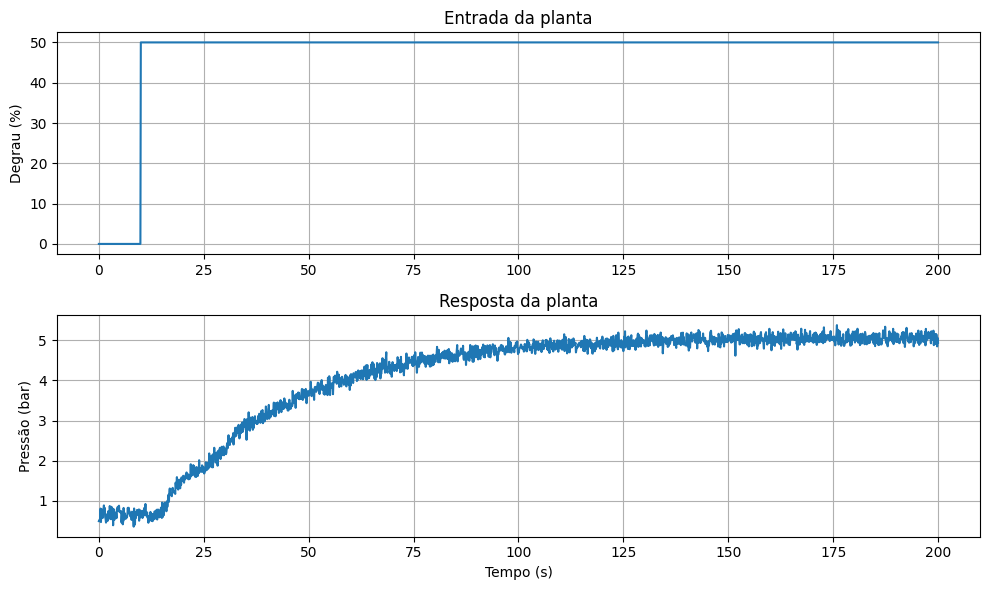

In [85]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, entrada)
plt.grid()
plt.ylabel('Degrau (%)')
plt.title('Entrada da planta')

plt.subplot(2, 1, 2)
plt.plot(t, saida)
plt.grid()
plt.xlabel('Tempo (s)')
plt.ylabel('Pressão (bar)')
plt.title('Resposta da planta')

plt.tight_layout()
plt.show()

podemos perceber que o setpoint do degrau é 50

In [86]:
setpoint = 50

### método de identificação de smith

In [87]:
# pegando as médias dos 10 valores iniciais e finais
n = 10
u0 = np.mean(entrada[:n])
uf = np.mean(entrada[-n:])


y0 = np.mean(saida[:n])
yf = np.mean(saida[-n:])

delta_u = uf - u0
delta_y = yf - y0

K = delta_y / delta_u

# Níveis de Smith
y_t1 = y0 + 0.283 * delta_y
y_t2 = y0 + 0.632 * delta_y

t1 = t[np.where(saida >= y_t1)[0][0]]
t2 = t[np.where(saida >= y_t2)[0][0]]

tau = 1.5 * (t2 - t1)
theta = t2 - tau

print(K)
print(tau)
print(theta)

0.08814492968715427
29.700000000000003
12.0


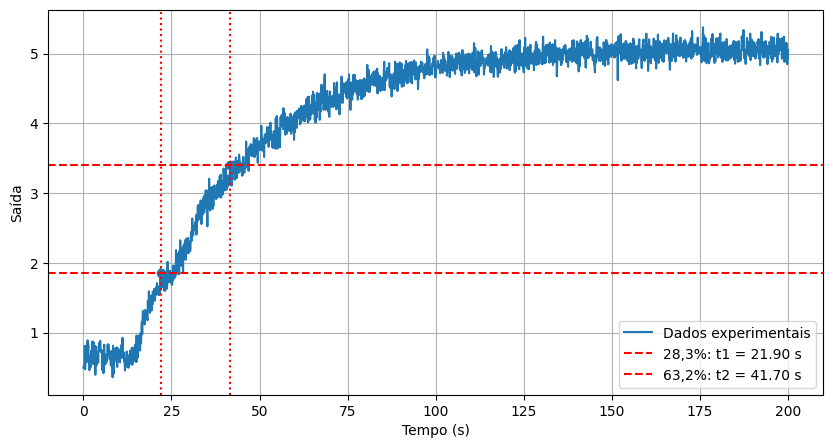

In [88]:
plt.figure(figsize=(10,5))

plt.plot(t, saida, label='Dados experimentais')

plt.axhline(y_t1, linestyle='--',
            label=f'28,3%: t1 = {t1:.2f} s',c='r')

plt.axhline(y_t2, linestyle='--',
            label=f'63,2%: t2 = {t2:.2f} s',c='r')

plt.axvline(t1, linestyle=':',c='r')
plt.axvline(t2, linestyle=':',c='r')

plt.scatter([t1, t2], [y_t1, y_t2])

plt.xlabel('Tempo (s)')
plt.ylabel('Saída')
plt.grid()
plt.legend()
plt.show()

### método de identificação de Sundaresan


In [89]:
# Níveis de Sundaresan
y_t1_sun = y0 + 0.353 * delta_y
y_t2_sun = y0 + 0.853 * delta_y

t1_sun = t[np.where(saida >= y_t1_sun)[0][0]]
t2_sun = t[np.where(saida >= y_t2_sun)[0][0]]

tau_sun = (2/3) * (t2_sun - t1_sun)
theta_sun = 1.3 * t1_sun - 0.29 * t2_sun

print(K)
print(tau_sun)
print(theta_sun)

0.08814492968715427
24.933333333333337
15.717000000000006


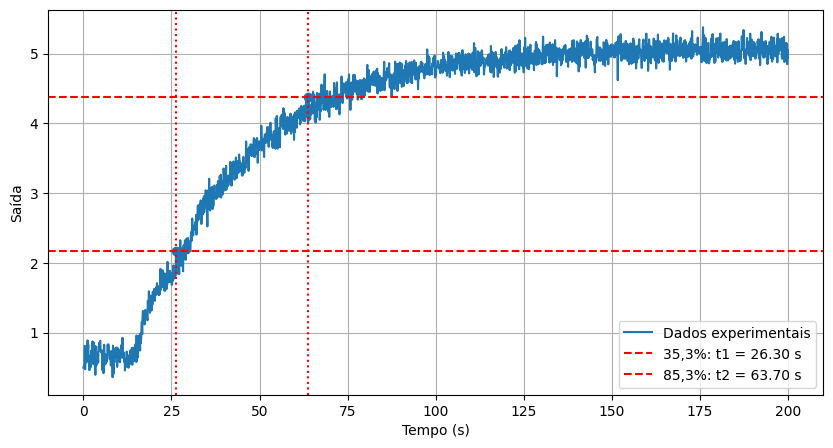

In [90]:
plt.figure(figsize=(10,5))

plt.plot(t, saida, label='Dados experimentais')

plt.axhline(y_t1_sun, linestyle='--',
            label=f'35,3%: t1 = {t1_sun:.2f} s',c='r')

plt.axhline(y_t2_sun, linestyle='--',
            label=f'85,3%: t2 = {t2_sun:.2f} s',c='r')

plt.axvline(t1_sun, linestyle=':',c='r')
plt.axvline(t2_sun, linestyle=':',c='r')

plt.scatter([t1_sun, t2_sun], [y_t1_sun, y_t2_sun])

plt.xlabel('Tempo (s)')
plt.ylabel('Saída')
plt.grid()
plt.legend()
plt.show()

### Resposta estimada pelo método de Smith

In [91]:
saida_smith = np.zeros_like(t, dtype=float)

for i in range(len(t)):
    if t[i] < theta:
        saida_smith[i] = y0
    else:
        saida_smith[i] = y0 + K * delta_u * (1 - np.exp(-(t[i] - theta) / tau))

### Resposta estimada pelo método de Sundaresan

In [92]:
saida_sundaresan = np.zeros_like(t, dtype=float)

for i in range(len(t)):
    if t[i] < theta_sun:
        saida_sundaresan[i] = y0
    else:
        saida_sundaresan[i] = y0 + K * delta_u * (1 - np.exp(-(t[i] - theta_sun) / tau_sun))

### Comparação dos métodos de identificação


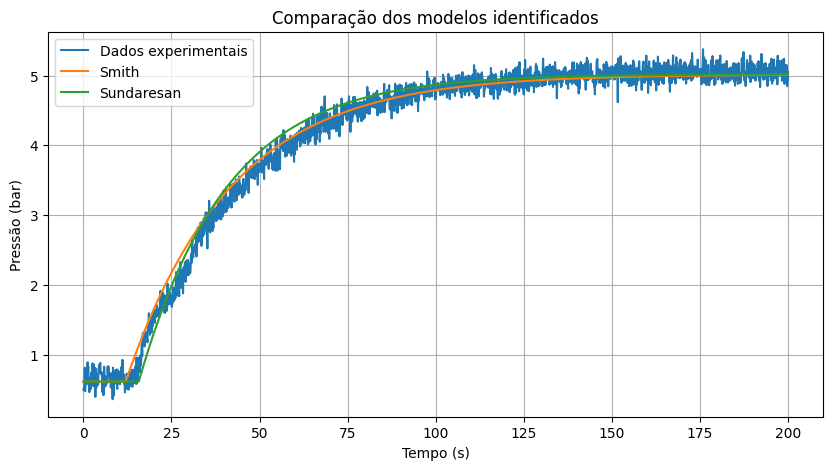

In [93]:

plt.figure(figsize=(10, 5))

plt.plot(t, saida, label='Dados experimentais')

plt.plot(t, saida_smith, label='Smith')

plt.plot(t,saida_sundaresan, label='Sundaresan')

plt.xlabel('Tempo (s)')
plt.ylabel('Pressão (bar)')
plt.title('Comparação dos modelos identificados')

plt.grid()
plt.legend()

plt.show()

### Cálculo do RMSE

In [94]:
rmse_smith = np.sqrt(np.mean((saida - saida_smith) ** 2))

rmse_sundaresan = np.sqrt(np.mean((saida - saida_sundaresan) ** 2))

print("RMSE Smith:", rmse_smith)
print("RMSE Sundaresan:", rmse_sundaresan)

RMSE Smith: 0.14722527590806803
RMSE Sundaresan: 0.15869647925131977


### Função de Transferência

Portanto, escolheremos o método de Smith já que resulta em um RMSE menor. Assim, usaremos os valores

K = 0,088

tau = 29,7

theta = 12

A função de transferência será do tipo FOPDT (First Order Plus Dead Time):


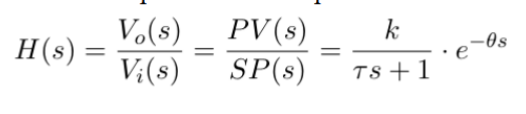

In [95]:
# Em python, precisamos usar a aproximação de Padé para o atraso

G = ct.tf([K], [tau, 1])
num_delay, den_delay = ct.pade(theta, 1) # Aproximação de Padé de 1° ordem do atraso
Delay = ct.tf(num_delay, den_delay)

# Modelo completo
H = G * Delay

print(H)

<TransferFunction>: sys[97]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     -0.08814 s + 0.01469
  --------------------------
  29.7 s^2 + 5.95 s + 0.1667


### Respostas em malha aberta e malha fechada

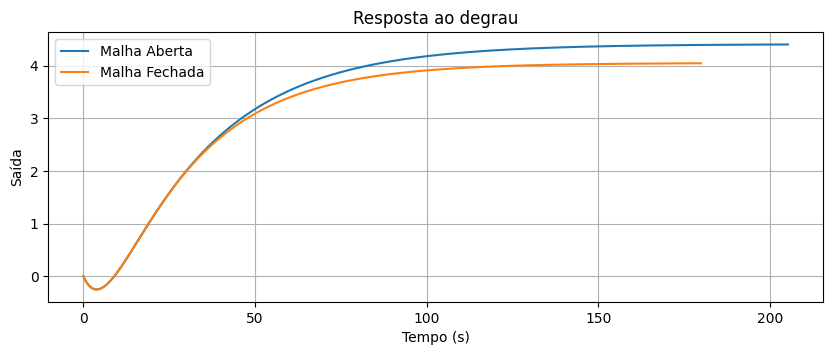

In [96]:
t_ma, y_ma = ct.step_response(H) # set point 50 do degrau
y_ma *= setpoint

T = ct.feedback(H, 1)
t_mf, y_mf = ct.step_response(T)
y_mf *= setpoint

plt.figure(figsize=(10,3.5))

plt.plot(t_ma, y_ma, label='Malha Aberta')
plt.plot(t_mf, y_mf, label = 'Malha Fechada')

plt.xlabel('Tempo (s)')
plt.ylabel('Saída')
plt.title('Resposta ao degrau')
plt.legend()
plt.grid()
plt.show()
# y_ma = y0 + delta_u * y_ma

tempo de subida - tr (intervalo necessário para que a amplitude varie de 10% a 90% do Valor Final)

tempo de acomodação  - ts (intervalo para o regime estacionário)

In [97]:
info_ma = ct.step_info(H)
info_mf = ct.step_info(T)

print("Malha aberta")
print(info_ma)

print("\nMalha fechada")
print(info_mf)

Malha aberta
{'RiseTime': 67.00801159131989, 'SettlingTime': 129.05246676846792, 'SettlingMin': 0.07948268786972268, 'SettlingMax': 0.08814492968715426, 'Overshoot': 0.0, 'Undershoot': 5.637755183981256, 'Peak': 0.08801215441332112, 'PeakTime': 205.1603317857695, 'SteadyStateValue': 0.08814492968715426}

Malha fechada
{'RiseTime': 59.06976815393883, 'SettlingTime': 114.66484406352832, 'SettlingMin': 0.0730372781043458, 'SettlingMax': 0.0810047699367549, 'Overshoot': 0.0, 'Undershoot': 6.1482330110344146, 'Peak': 0.0808733267235856, 'PeakTime': 179.8153236450785, 'SteadyStateValue': 0.0810047699367549}


O tempo de subida do sistema em malha aberta é mais alto. Além disso, seu tempo de acomodação também é superior. Logo, podemos perceber que a realimentação deixa a resposta do sistema mais rápida.  

In [98]:
# Erros em malha aberta e malha fechada sem controlador 
# set point do degrau (50) menos o valor que estabiliza

erro_processo_ma = setpoint - np.mean(y_ma[-20:])
erro_processo_mf = setpoint - np.mean(y_mf[-20:])
print("Erro malha aberta")
print(erro_processo_ma)
print("\nErro malha fechada")
print(erro_processo_mf)

Erro malha aberta
45.601515324406215

Erro malha fechada
45.958953292181256


### Controlador PID

parâmetros do controlador PID


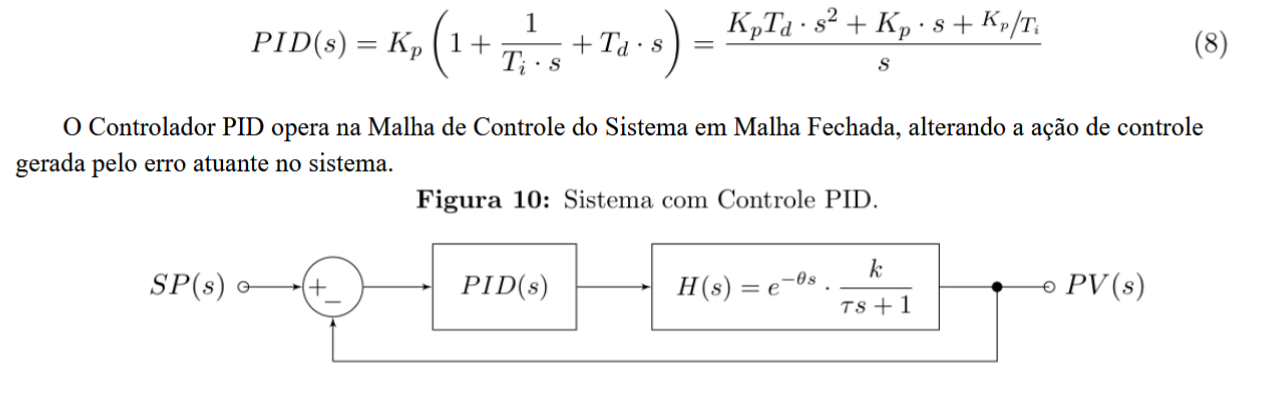

#### IMC


In [99]:
# Considerando o critério de desempenho lambda/theta > 0,8
lamb_min = 0.8 * theta
print(lamb_min)

9.600000000000001


In [100]:
lamb = 10 # posso considerar isso mesmo?
Kp_imc = (2*tau + theta)/(K * (2*lamb + theta))
Ti_imc = tau + theta/2
Td_imc = (tau * theta)/(2*tau + theta)

In [101]:
# parte proporcional
numKp_imc = np.array([Kp_imc])
denKp_imc = np.array([1])
HKp_imc = ct.tf(numKp_imc,denKp_imc)

# parte integral
numKi_imc = np.array([Kp_imc])
denKi_imc = np.array([Ti_imc,0])
HKi_imc = ct.tf(numKi_imc,denKi_imc)

# parte derivativa
numKd_imc = np.array([Kp_imc*Td_imc,0])
denKd_imc = np.array([1])
HKd_imc = ct.tf(numKd_imc,denKd_imc)

# juntando P + I
Hctrl1_imc = ct.parallel(HKp_imc, HKi_imc)
# P+I+D
Hctrl_imc = ct.parallel(Hctrl1_imc, HKd_imc)

# colocando o PID em série com a planta
Hdel_imc = ct.series(H, Hctrl_imc)

# fechando a malha
Hcl_imc = ct.feedback(Hdel_imc, 1)

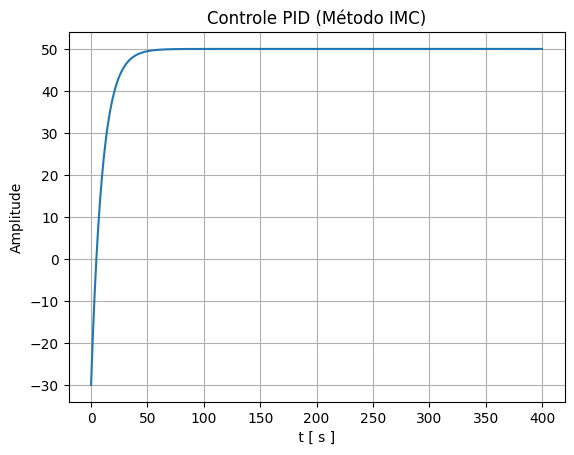

In [102]:
t = np.linspace(0,400,1000)
t_imc, y_imc = ct.step_response(Hcl_imc,t) 
y_imc *= setpoint
plt.plot(t, y_imc)

plt.xlabel ( ' t [ s ] ')
plt.ylabel('Amplitude')
plt.title('Controle PID (Método IMC)')

plt.grid ()
plt.show()

In [103]:
info_imc = ct.step_info(Hcl_imc)
info_imc

{'RiseTime': 21.630344812974396,
 'SettlingTime': 43.95844268443184,
 'SettlingMin': 0.9018254836253893,
 'SettlingMax': 1.0,
 'Overshoot': 0.0,
 'Undershoot': 60.0,
 'Peak': 0.9984000000000003,
 'PeakTime': 69.07755278982145,
 'SteadyStateValue': 1.0}

critério de desempenho

In [104]:
# Considerando o tempo de resposta como o tempo de acomodação mínimo
tresposta_imc = info_imc['SettlingMin']

#### CHR sem sobrevalor

In [105]:
Kp_chr = 0.6*theta / (K * theta)
Ti_chr = theta
Td_chr = theta/2

In [106]:
# parte proporcional
numKp_chr = np.array([Kp_chr])
denKp_chr = np.array([1])
HKp_chr = ct.tf(numKp_chr,denKp_chr)

# parte integral
numKi_chr = np.array([Kp_chr])
denKi_chr = np.array([Ti_chr,0])
HKi_chr = ct.tf(numKi_chr,denKi_chr)

# parte derivativa
numKd_chr = np.array([Kp_chr*Td_chr,0])
denKd_chr = np.array([1])
HKd_chr = ct.tf(numKd_chr,denKd_chr)

# juntando P + I
Hctrl1_chr = ct.parallel(HKp_chr, HKi_chr)
# P+I+D
Hctrl_chr = ct.parallel(Hctrl1_chr, HKd_chr)

# colocando o PID em série com a planta
Hdel_chr = ct.series(H, Hctrl_chr)

# fechando a malha
Hcl_chr = ct.feedback(Hdel_chr, 1)

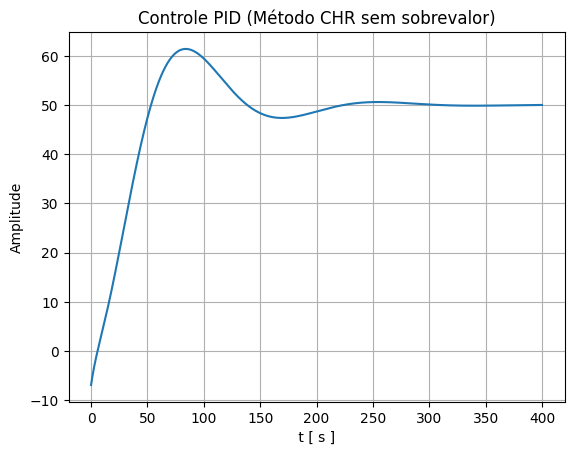

In [107]:
t_chr, y_chr = ct.step_response(Hcl_chr,t) 
y_chr *= setpoint
plt.plot(t_chr, y_chr)

plt.xlabel ( ' t [ s ] ')
plt.ylabel('Amplitude')
plt.title('Controle PID (Método CHR sem sobrevalor)')

plt.grid ()
plt.show()

In [108]:
info_chr = ct.step_info(Hcl_chr)
info_chr

{'RiseTime': 36.35923461481109,
 'SettlingTime': 205.32273664834497,
 'SettlingMin': 0.9074109800834568,
 'SettlingMax': 1.2280197593157536,
 'Overshoot': 22.801975931575356,
 'Undershoot': 13.793103448275856,
 'Peak': 1.2280197593157536,
 'PeakTime': 84.12528793230801,
 'SteadyStateValue': 1.0}

Métrica de desempenho

In [109]:
tresposta_chr = info_chr['SettlingMin']

In [110]:
erro_processo_imc = np.abs(setpoint - np.mean(y_imc[-20:]))
erro_processo_chr = np.abs(setpoint - np.mean(y_chr[-20:]))
print("Erro malha controlador IMC")
print(erro_processo_imc)
print("\nErro malha controlador CHR")
print(erro_processo_chr)

Erro malha controlador IMC
1.1368683772161603e-13

Erro malha controlador CHR
0.003081842766981424


Comparação dos dois gráficos

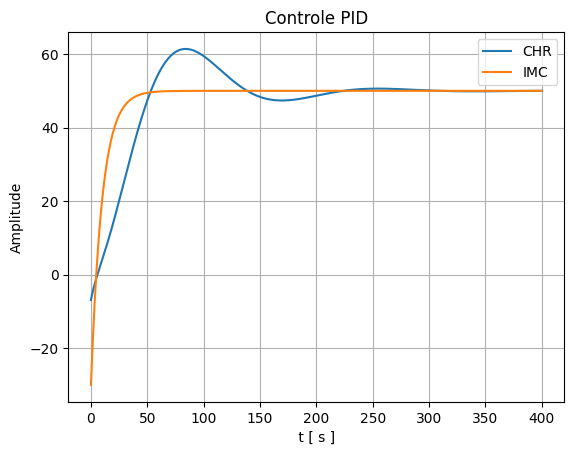

In [112]:
plt.plot(t_chr, y_chr,label='CHR')
plt.plot(t_imc, y_imc,label='IMC')

plt.xlabel ( ' t [ s ] ')
plt.ylabel('Amplitude')
plt.title('Controle PID')
plt.legend()
plt.grid ()
plt.show()

In [113]:
print(f'Tempo de resposta IMC: {tresposta_imc}')
print(f'Tempo de resposta CHR: {tresposta_chr}')

Tempo de resposta IMC: 0.9018254836253893
Tempo de resposta CHR: 0.9074109800834568


Apesar de próximos, o método IMC apresenta menor tempo de resposta. Ou seja, é mais adequada considerando esse critério de desempenho.